## Connect to Google Drive

In [1]:
from google.colab import drive
# Unmount if previously partially attached
try:
    drive.flush_and_unmount()
    print('Unmounted existing drive.')
except:
    pass

# Attempt mount with force_remount
drive.mount('/content/drive', force_remount=True)

Drive not mounted, so nothing to flush and unmount.
Unmounted existing drive.
Mounted at /content/drive


## Install Libraries

In [4]:
# Use more flexible version requirements to avoid installation conflicts
!pip install numpy ultralytics mediapipe

  Using cached ultralytics-8.4.43-py3-none-any.whl.metadata (39 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 96.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 16.6 MB/s eta 0:00:00
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0


## Importing Libraries

In [5]:
# Import necessary libraries for the project

import matplotlib.pyplot as plt  # For plotting and visualization
import cv2  # OpenCV for image and video processing
import os  # For interacting with the operating system (file paths, directories)
import numpy as np  # For numerical operations and array handling

# Ensure libraries are installed before importing
try:
    from ultralytics import YOLO
    import mediapipe as mp
except ImportError:
    print("Required libraries not found. Please run the install cell (ah_eCclQ3Af8) above.")

from sklearn.model_selection import train_test_split  # For splitting data into train/test sets
from sklearn.preprocessing import MinMaxScaler, LabelEncoder  # For feature scaling and label encoding
from sklearn.linear_model import LogisticRegression  # Logistic Regression classifier
from sklearn.svm import SVC  # Support Vector Classifier
from sklearn.ensemble import RandomForestClassifier  # Random Forest classifier
from xgboost import XGBClassifier  # XGBoost classifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix  # Evaluation metrics
import seaborn as sns  # For advanced data visualization (heatmaps, etc.)
import pandas as pd  # For data manipulation and analysis
import joblib  # For saving and loading models and preprocessing objects
from collections import Counter  # For counting occurrences of elements (e.g., predictions)
import shutil  # For high-level file operations (copying, removing directories)
from IPython.display import display, Image  # Import display and Image from IPython.display for displaying images in the notebook.

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [6]:
# Video Prediction Path
video_path = '/content/drive/MyDrive/Data/Dancing/2-#jennielikejennie #jennie #likejennie #dancecove7493853985120505094.mp4'


# Object Detection

In [7]:
!pip install roboflow==1.1.48 --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 24.6 MB/s eta 0:00:00


In [8]:
import os # Get the current working directory
HOME = os.getcwd() # Get the current working directory
print(HOME) # Print the current working directory


/content


In [9]:
from IPython import display  # Import the display module from IPython for clearing outputs and displaying images.
display.clear_output()  # Clear the current output in the Jupyter Notebook cell.

import ultralytics  # Import the ultralytics library, which is used for YOLO model training and inference.
ultralytics.checks()  # Run checks to ensure the ultralytics library and its dependencies are properly installed.

from ultralytics import YOLO  # Import the YOLO class from the ultralytics library for model creation and usage.
from IPython.display import display, Image  # Import display and Image from IPython.display for displaying images in the notebook.


Ultralytics 8.4.43 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.4/112.6 GB disk)


In [10]:
!mkdir -p {HOME}/datasets  # Create a directory named 'datasets' inside the current working directory if it doesn't already exist.
%cd {HOME}/datasets  # Change the current working directory to the newly created 'datasets' directory.

from roboflow import Roboflow  # Import the Roboflow class from the roboflow library.

rf = Roboflow(api_key="UGmDlp3rOig59tfYSH9m")  # Initialize the Roboflow object with the provided API key.

project = rf.workspace("alexa-fiverr").project("alexa-tybnf")  # Access the specific project within the specified workspace.

dataset = project.version(1).download("yolov8")  # Download version 3 of the dataset in YOLOv8 format.


[Errno 2] No such file or directory: '/content/datasets # Change the current working directory to the newly created datasets directory.'
/content
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Alexa-1 in yolov8:: 100%|██████████| 6522/6522 [00:00<00:00, 7528.35it/s]


In [11]:
%cd {HOME}  # Change the current working directory to the value stored in the HOME variable.

!yolo task=detect mode=train model=yolov8s.pt data={dataset.location}/data.yaml epochs=5 imgsz=800 plots=True
# Run the YOLO command-line interface to train a detection model:
# - task=detect: Specifies the task as object detection.
# - mode=train: Sets the mode to training.
# - model=yolov8s.pt: Specifies the pre-trained YOLOv8s model to use as a starting point.
# - data={dataset.location}/data.yaml: Specifies the path to the dataset configuration file.
# - epochs=5: Sets the number of training epochs to 5.
# - imgsz=800: Sets the image size for training to 800x800 pixels.
# - plots=True: Enables the generation of training plots.


[Errno 2] No such file or directory: '/content # Change the current working directory to the value stored in the HOME variable.'
/content
Ultralytics 8.4.43 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Alexa-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=800, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mo

[Errno 2] No such file or directory: '/content # Change the current working directory to the value stored in the HOME variable.'
/content


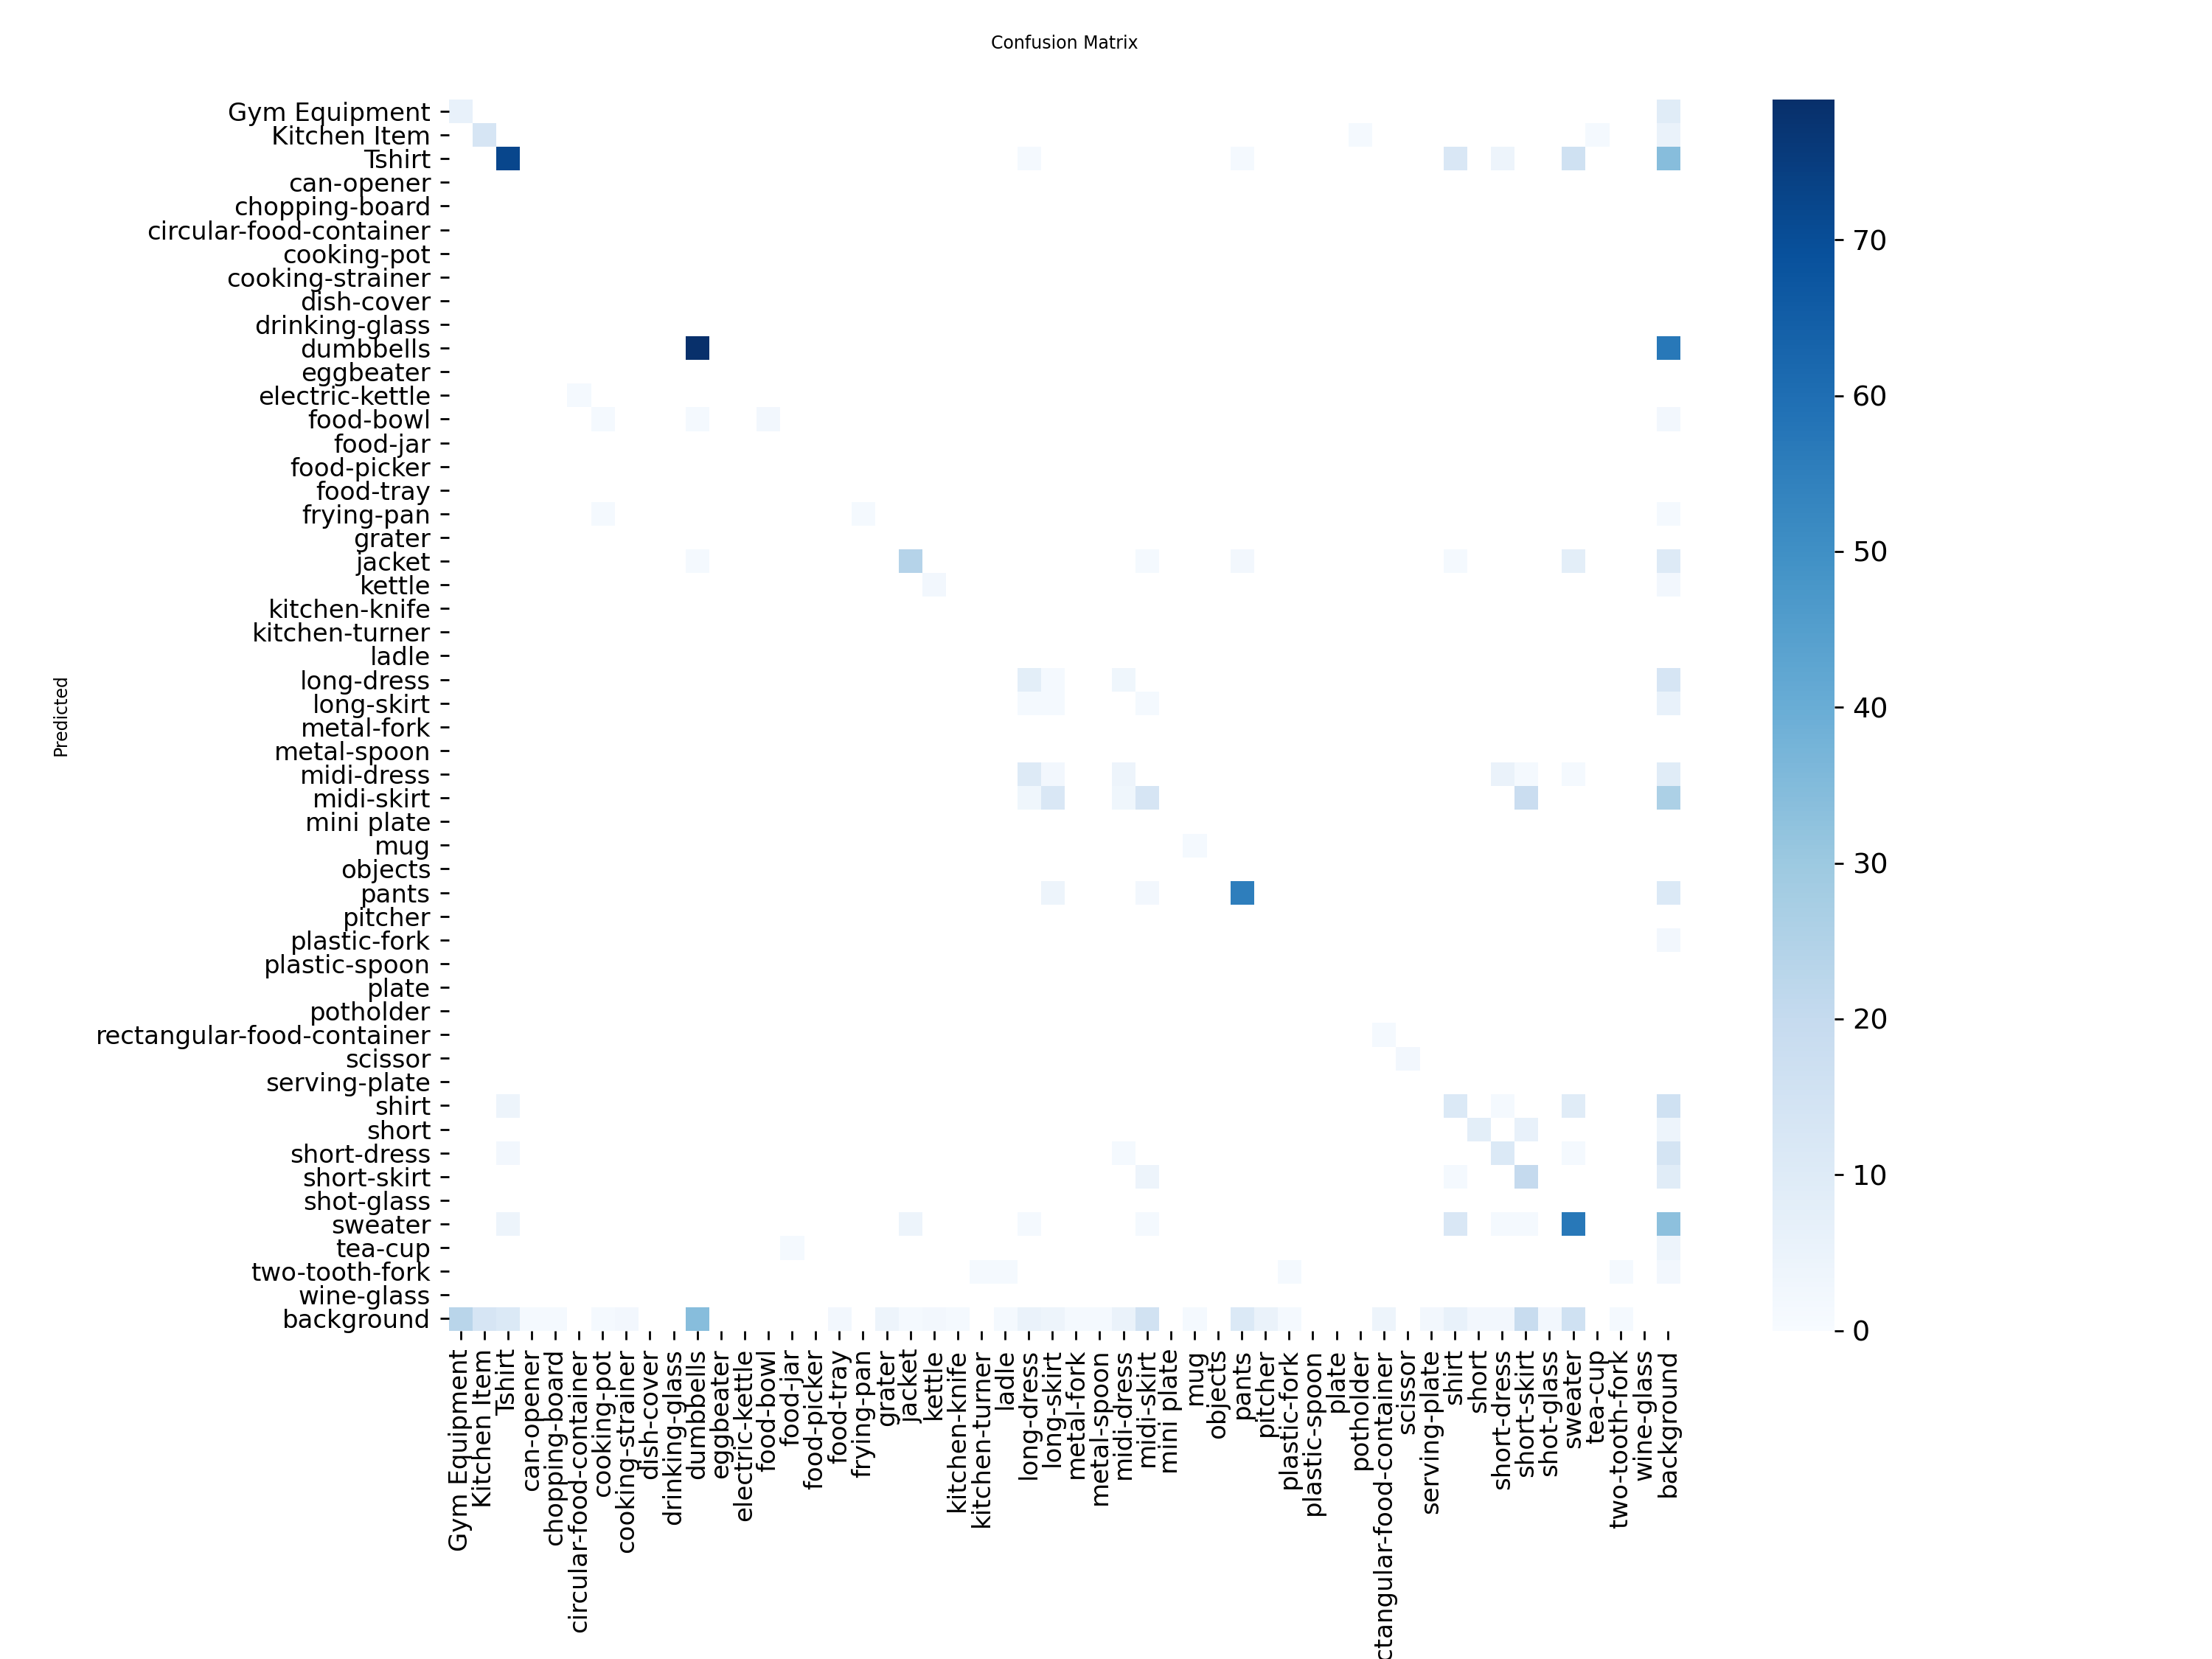

In [12]:
%cd {HOME}  # Change the current working directory to the value stored in the HOME variable.
Image(filename=f'{HOME}/runs/detect/train/confusion_matrix.png', width=600)  # Display the confusion matrix image from the specified path with a width of 600 pixels.


/content


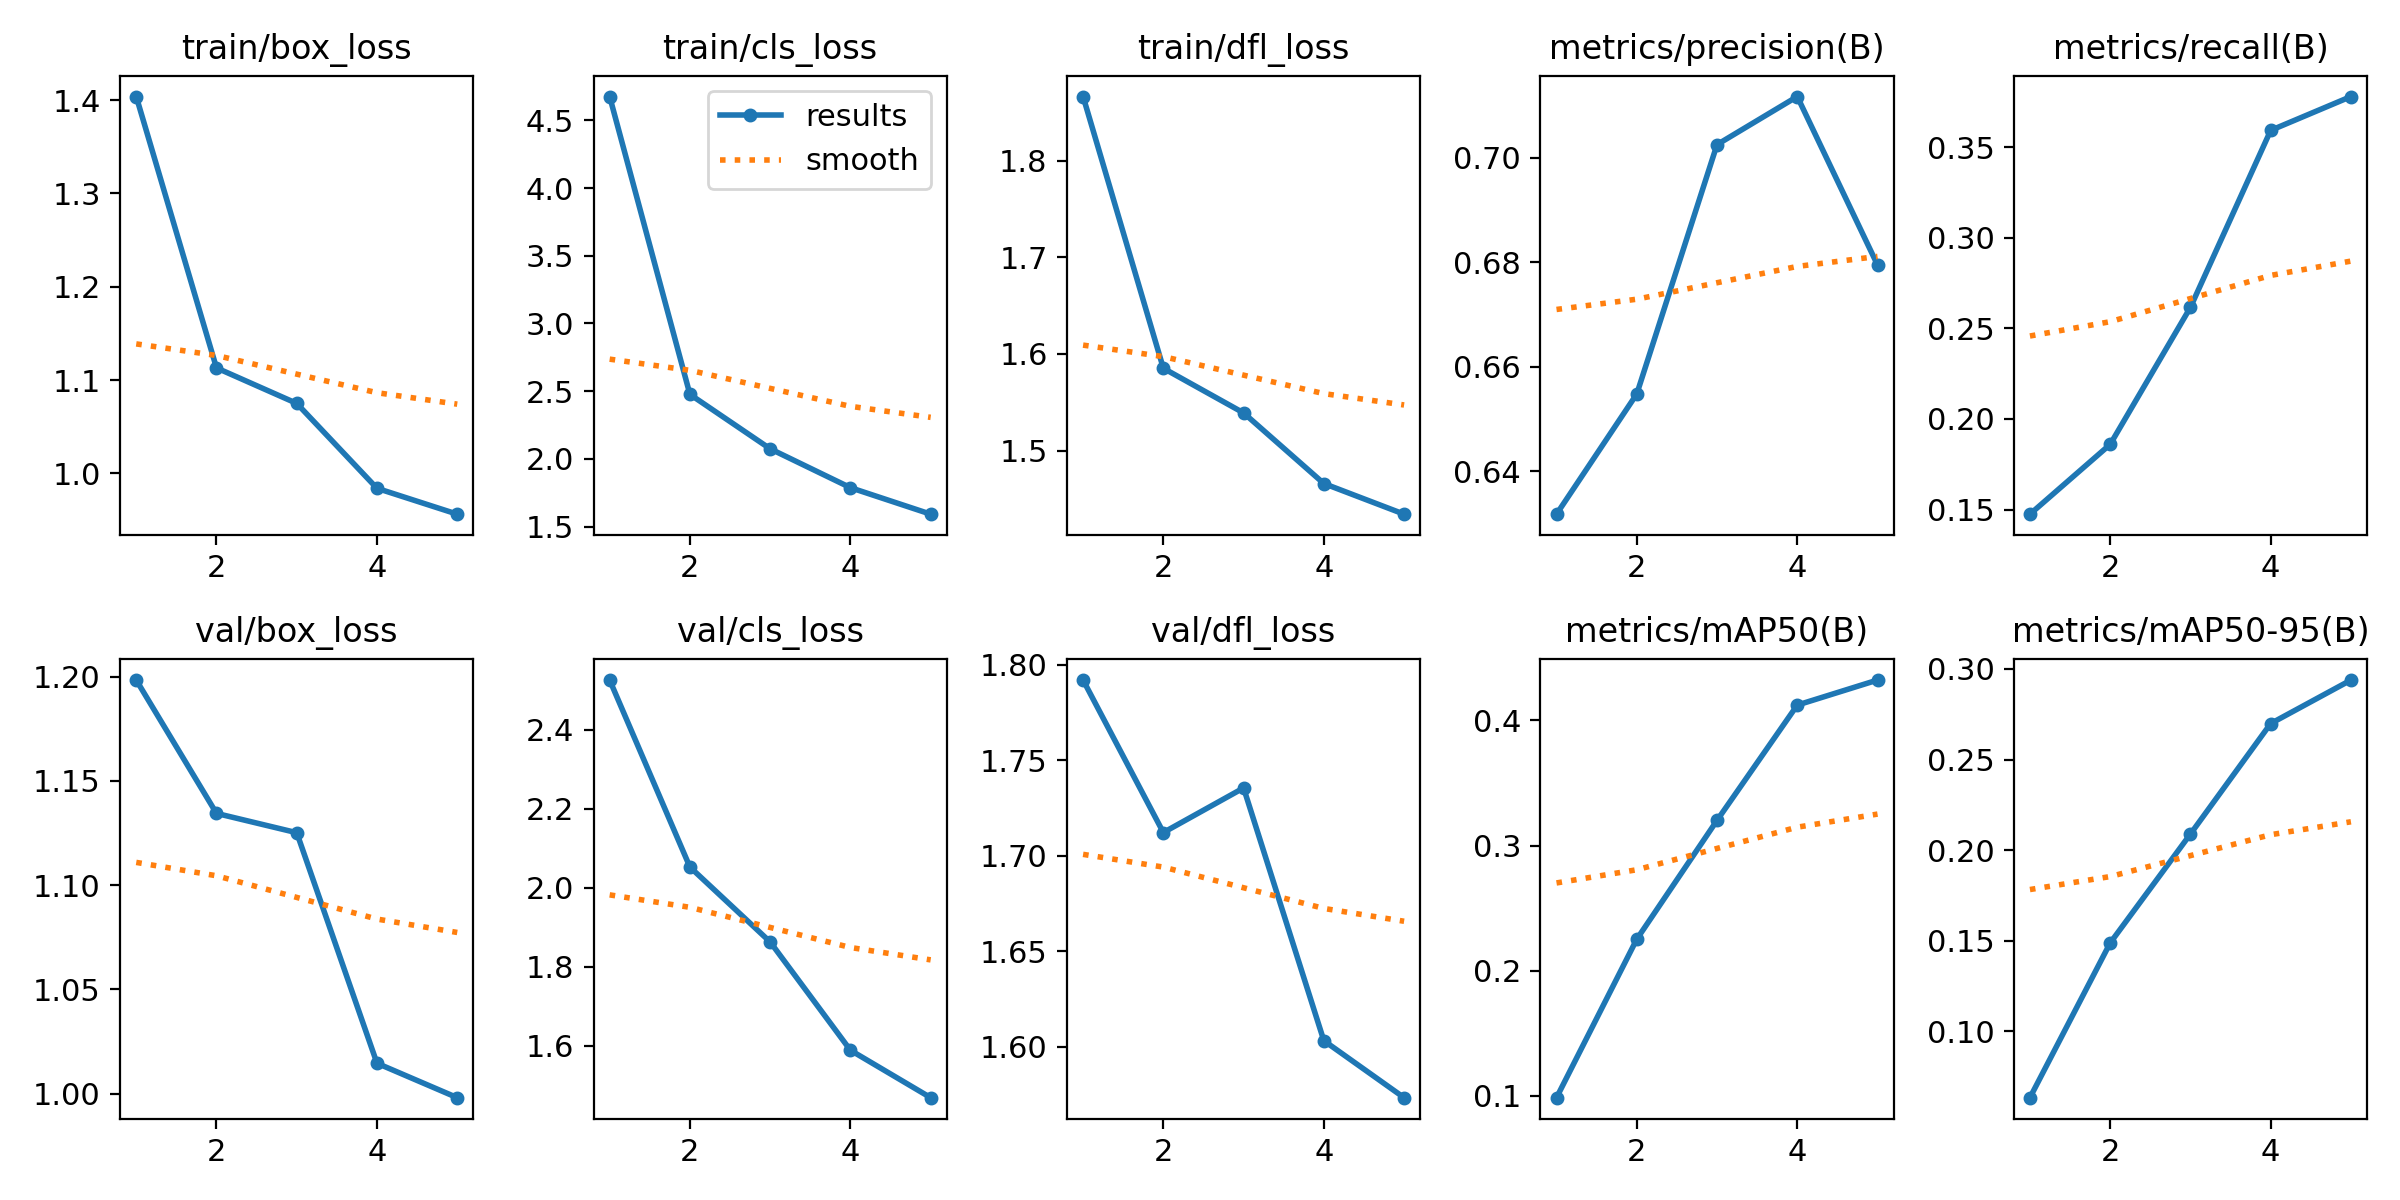

In [13]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train/results.png', width=600)


In [15]:
%cd {HOME}
import os

r_curve_path = f'{HOME}/runs/detect/train/R_curve.png'
if os.path.exists(r_curve_path):
    display(Image(filename=r_curve_path, width=600))
else:
    print(f"R_curve.png not found at {r_curve_path}. It may not have been generated due to the low number of epochs.")

/content
R_curve.png not found at /content/runs/detect/train/R_curve.png. It may not have been generated due to the low number of epochs.


In [17]:
%cd {HOME}
import os

f1_curve_path = f'{HOME}/runs/detect/train/F1_curve.png'
if os.path.exists(f1_curve_path):
    display(Image(filename=f1_curve_path, width=600))
else:
    print(f"F1_curve.png not found at {f1_curve_path}. This is common with few epochs.")

/content
F1_curve.png not found at /content/runs/detect/train/F1_curve.png. This is common with few epochs.


In [20]:
%cd {HOME}
import os

pr_curve_path = f'{HOME}/runs/detect/train/PR_curve.png'
if os.path.exists(pr_curve_path):
    display(Image(filename=pr_curve_path, width=600))
else:
    print(f"PR_curve.png not found at {pr_curve_path}. This typically occurs when the number of training epochs is too low to generate reliable curves.")

/content
PR_curve.png not found at /content/runs/detect/train/PR_curve.png. This typically occurs when the number of training epochs is too low to generate reliable curves.


/content


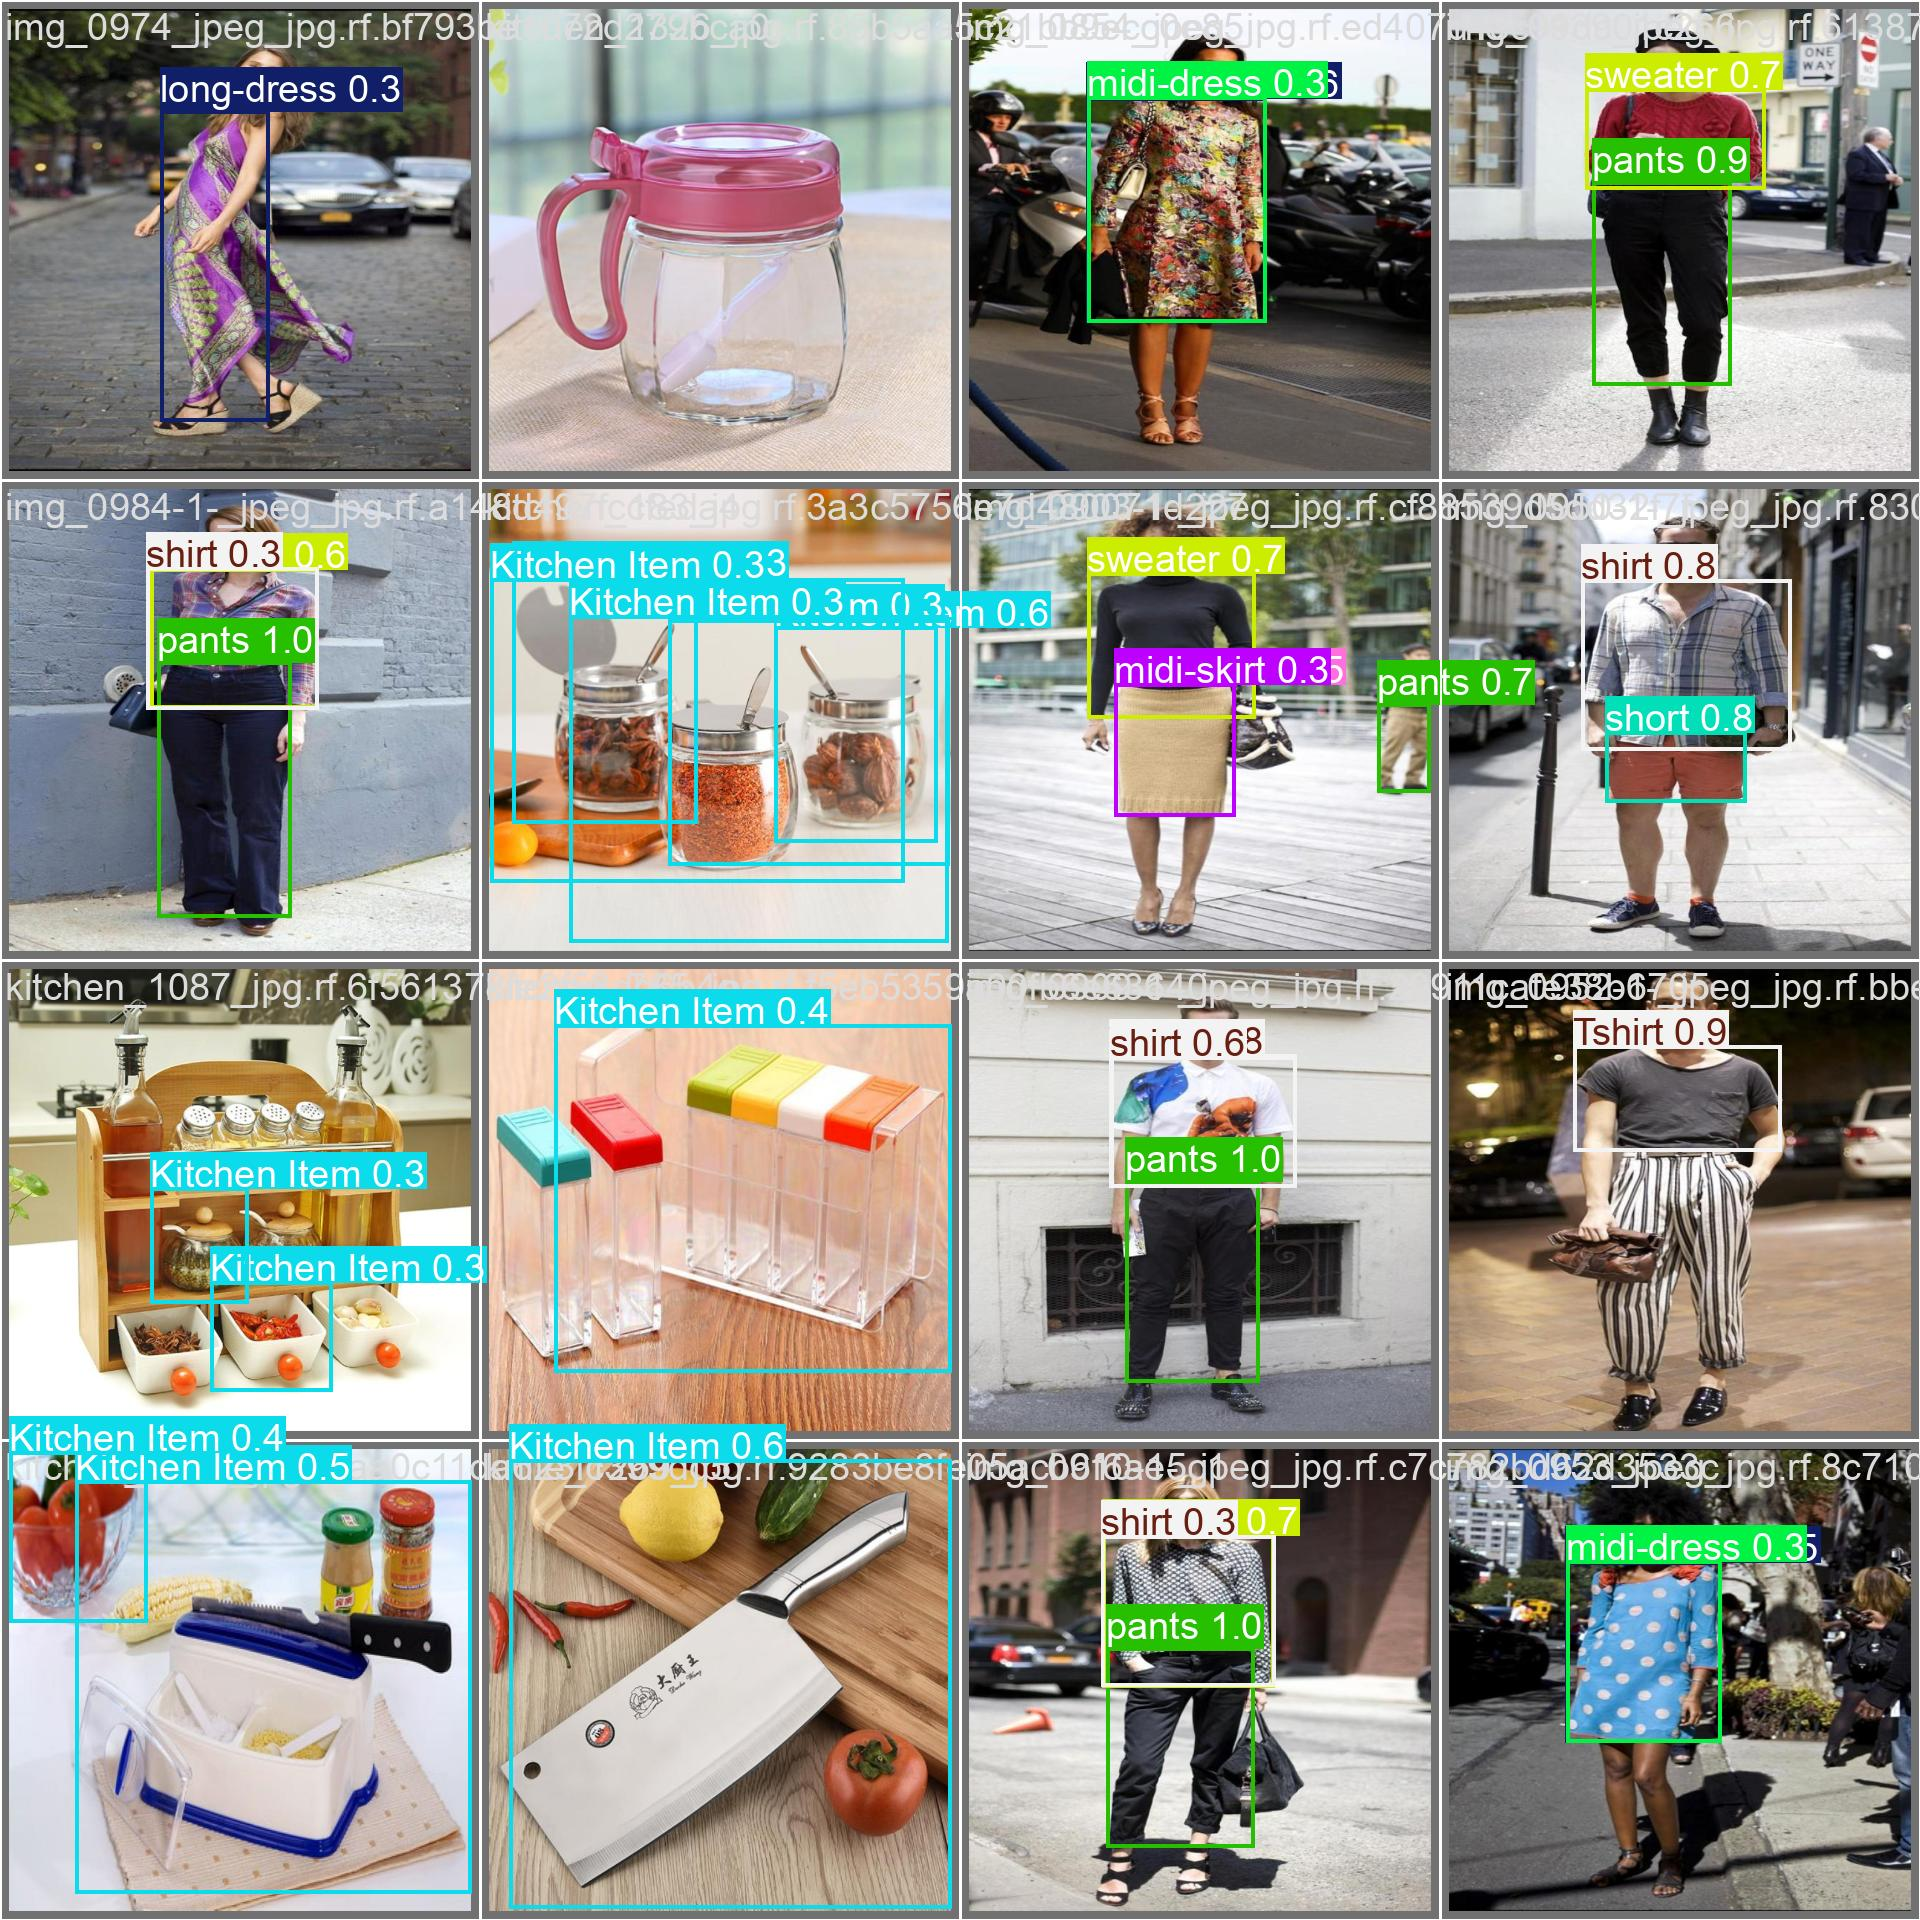

In [19]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train/val_batch0_pred.jpg', width=600)


In [22]:
from ultralytics import YOLO
import os

# Validate if the video file exists before running inference
if not os.path.exists(video_path):
    print(f"Error: Video not found at {video_path}")
    parent_dir = os.path.dirname(video_path)
    if os.path.exists(parent_dir):
        print(f"Contents of {parent_dir}:")
        print(os.listdir(parent_dir))
    else:
        print(f"The directory {parent_dir} also does not exist. Please check your Drive path.")
else:
    model = YOLO("/content/runs/detect/train/weights/best.pt")
    custom_output_dir = "/content"
    output_video_path = os.path.join(custom_output_dir, "result.mp4")

    # Run inference
    results = model(video_path, save=True, save_dir=custom_output_dir)

Error: Video not found at /content/drive/MyDrive/Data/Dancing/2-#jennielikejennie #jennie #likejennie #dancecove7493853985120505094.mp4
The directory /content/drive/MyDrive/Data/Dancing also does not exist. Please check your Drive path.
